In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd

# Load all three datasets
with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/Apache_issues.json') as f:
    apache = json.load(f)

with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/Jira_issues.json') as f:
    jira = json.load(f)

with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/MongoDB_issues.json') as f:
    mongodb = json.load(f)

print(f"Apache: {len(apache)} issues")
print(f"Jira: {len(jira)} issues")
print(f"MongoDB: {len(mongodb)} issues")
print(f"Total: {len(apache) + len(jira) + len(mongodb)} issues")

Mounted at /content/drive
Apache: 10000 issues
Jira: 2000 issues
MongoDB: 8000 issues
Total: 20000 issues


In [ ]:
def flatten_issue(issue, source):
    fields = issue.get('fields', {})
    return {
        'id': issue.get('id'),
        'key': issue.get('key'),
        'source': source,
        'created': fields.get('created'),
        'resolutiondate': fields.get('resolutiondate'),
        'duedate': fields.get('duedate'),
        'status': fields.get('status', {}).get('name') if fields.get('status') else None,
        'priority': fields.get('priority', {}).get('name') if fields.get('priority') else None,
        'issuetype': fields.get('issuetype', {}).get('name') if fields.get('issuetype') else None,
        'assignee': fields.get('assignee', {}).get('displayName') if fields.get('assignee') else None,
        'story_points': fields.get('story_points') or fields.get('customfield_12310293') or fields.get('customfield_10555'),
        'timespent': fields.get('timespent'),
        'timeoriginalestimate': fields.get('timeoriginalestimate'),
        'timeestimate': fields.get('timeestimate'),
        'summary': fields.get('summary'),
    }

# Flatten all three
rows = []
for issue in apache:
    rows.append(flatten_issue(issue, 'Apache'))
for issue in jira:
    rows.append(flatten_issue(issue, 'Jira'))
for issue in mongodb:
    rows.append(flatten_issue(issue, 'MongoDB'))

df = pd.DataFrame(rows)
print(df.shape)
print(df.dtypes)
df.head()

(20000, 15)
id                       object
key                      object
source                   object
created                  object
resolutiondate           object
duedate                  object
status                   object
priority                 object
issuetype                object
assignee                 object
story_points            float64
timespent               float64
timeoriginalestimate    float64
timeestimate            float64
summary                  object
dtype: object


,id,key,source,created,resolutiondate,duedate,status,priority,issuetype,assignee,story_points,timespent,timeoriginalestimate,timeestimate,summary
0,12705174,SPARK-515,Apache,0010-04-03T23:04:00.000+0000,2012-10-19T22:50:39.000+0000,None,Resolved,None,Bug,None,NaN,NaN,NaN,NaN,Make it easier to run external code on a Nexus...
1,12705172,SPARK-514,Apache,0010-04-03T23:05:00.000+0000,2012-10-19T22:50:36.000+0000,None,Resolved,None,Bug,None,NaN,NaN,NaN,NaN,Merge fault tolerance code into master branch
2,12705483,SPARK-513,Apache,0010-04-03T23:06:00.000+0000,2012-10-19T22:50:22.000+0000,None,Resolved,None,Bug,None,NaN,NaN,NaN,NaN,Make NexusScheduler more efficient by keeping ...
3,12705470,SPARK-512,Apache,0010-04-03T23:07:00.000+0000,2012-10-19T22:50:37.000+0000,None,Resolved,None,Bug,None,NaN,NaN,NaN,NaN,Shuffle operation
4,12705481,SPARK-511,Apache,0010-04-03T23:09:00.000+0000,2012-10-19T22:50:32.000+0000,None,Resolved,None,Bug,None,NaN,NaN,NaN,NaN,Unify the API and implementation of ParallelAr...


In [ ]:
print("=== Issue Type Distribution ===")
print(df['issuetype'].value_counts())

print("\n=== By Source ===")
print(df.groupby(['source', 'issuetype']).size().unstack(fill_value=0))

=== Issue Type Distribution ===
issuetype
Bug                12541
Improvement         3251
Task                2001
New Feature         1037
Suggestion          1017
Question             134
Sub-task              13
Wish                   3
Support Request        3
Name: count, dtype: int64

=== By Source ===
issuetype   Bug  Improvement  New Feature  Question  Sub-task  Suggestion  \
source                                                                      
Apache     8357         1232          274         0         0           0   
Jira        975            0            0         0         5        1017   
MongoDB    3209         2019          763       134         8           0   

issuetype  Support Request  Task  Wish  
source                                  
Apache                   0   134     3  
Jira                     3     0     0  
MongoDB                  0  1867     0  


In [ ]:
# Keep only delivery-relevant issue types
keep_types = ['Bug', 'Improvement', 'Task', 'New Feature', 'Suggestion', 'Sub-task']
df_filtered = df[df['issuetype'].isin(keep_types)].copy()

print(f"Before filter: {len(df)}")
print(f"After filter: {len(df_filtered)}")
print(f"Removed: {len(df) - len(df_filtered)}")
print(f"\nRetained issue types:\n{df_filtered['issuetype'].value_counts()}")

Before filter: 20000
After filter: 19860
Removed: 140

Retained issue types:
issuetype
Bug            12541
Improvement     3251
Task            2001
New Feature     1037
Suggestion      1017
Sub-task          13
Name: count, dtype: int64


In [ ]:
# Convert date columns to datetime
df_filtered['created'] = pd.to_datetime(df_filtered['created'], utc=True, errors='coerce')
df_filtered['resolutiondate'] = pd.to_datetime(df_filtered['resolutiondate'], utc=True, errors='coerce')

# Calculate actual resolution time in days
df_filtered['actual_days'] = (df_filtered['resolutiondate'] - df_filtered['created']).dt.total_seconds() / 86400

# Estimated days from timeoriginalestimate (stored in seconds)
df_filtered['estimated_days'] = df_filtered['timeoriginalestimate'] / 86400

# Engineer delay label
# Delayed = actual resolution time exceeded estimate by more than 20%
df_filtered['delay_ratio'] = (
    (df_filtered['actual_days'] - df_filtered['estimated_days']) / df_filtered['estimated_days']
)
df_filtered['is_delayed'] = (df_filtered['delay_ratio'] > 0.2).astype(int)

# Summary
print("=== Delay Label Distribution ===")
print(df_filtered['is_delayed'].value_counts())
print(f"\nClass balance: {df_filtered['is_delayed'].mean():.1%} delayed")

print(f"\n=== Data Availability ===")
print(f"Has resolution date: {df_filtered['resolutiondate'].notna().sum()}")
print(f"Has original estimate: {df_filtered['estimated_days'].notna().sum()}")
print(f"Has both (fully labelled): {df_filtered[df_filtered['resolutiondate'].notna() & df_filtered['estimated_days'].notna()].shape[0]}")

=== Delay Label Distribution ===
is_delayed
0    19821
1       39
Name: count, dtype: int64

Class balance: 0.2% delayed

=== Data Availability ===
Has resolution date: 19323
Has original estimate: 85
Has both (fully labelled): 41


/tmp/ipykernel_2903/1068403714.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['created'] = pd.to_datetime(df_filtered['created'], utc=True, errors='coerce')


In [ ]:
# Alternative delay label - uses duedate instead of timeoriginalestimate
df_filtered['duedate'] = pd.to_datetime(df_filtered['duedate'], utc=True, errors='coerce')

# Strategy 2: Delayed if resolved after due date
df_filtered['is_delayed_v2'] = (
    (df_filtered['resolutiondate'] > df_filtered['duedate']) &
    df_filtered['duedate'].notna() &
    df_filtered['resolutiondate'].notna()
).astype(int)

# Strategy 3: Delayed if actual_days > median resolution time for that issue type
median_days = df_filtered.groupby('issuetype')['actual_days'].transform('median')
df_filtered['is_delayed_v3'] = (
    (df_filtered['actual_days'] > median_days * 1.5) &
    df_filtered['actual_days'].notna()
).astype(int)

print("=== Strategy 2: Due Date Based ===")
print(df_filtered['is_delayed_v2'].value_counts())
print(f"Has due date: {df_filtered['duedate'].notna().sum()}")

print("\n=== Strategy 3: Median-Based (no estimate needed) ===")
print(df_filtered['is_delayed_v3'].value_counts())
print(f"Class balance: {df_filtered['is_delayed_v3'].mean():.1%} delayed")

=== Strategy 2: Due Date Based ===
is_delayed_v2
0    19855
1        5
Name: count, dtype: int64
Has due date: 9

=== Strategy 3: Median-Based (no estimate needed) ===
is_delayed_v3
0    13502
1     6358
Name: count, dtype: int64
Class balance: 32.0% delayed


In [ ]:
# Set official delay label
df_filtered['is_delayed'] = df_filtered['is_delayed_v3']

# Drop intermediate columns
df_model = df_filtered[[
    'id', 'key', 'source', 'issuetype', 'priority', 'status',
    'assignee', 'created', 'resolutiondate', 'actual_days',
    'story_points', 'timespent', 'summary', 'is_delayed'
]].copy()

print(f"Final dataset shape: {df_model.shape}")
print(f"Delayed: {df_model['is_delayed'].sum()} ({df_model['is_delayed'].mean():.1%})")
print(f"On-time: {(df_model['is_delayed']==0).sum()}")

# Save to Google Drive
df_model.to_csv('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/jira_labelled_dataset.csv', index=False)
print("\nSaved to Google Drive.")

Final dataset shape: (19860, 14)
Delayed: 6358 (32.0%)
On-time: 13502

Saved to Google Drive.


In [ ]:
# Step 1: Feature Engineering
df_features = df_model.copy()

# Extract time features from created date
df_features['created'] = pd.to_datetime(df_features['created'], utc=True, errors='coerce')
df_features['created_hour'] = df_features['created'].dt.hour
df_features['created_dayofweek'] = df_features['created'].dt.dayofweek
df_features['created_month'] = df_features['created'].dt.month
df_features['created_year'] = df_features['created'].dt.year

# Encode categorical columns
df_features['priority_enc'] = df_features['priority'].astype('category').cat.codes
df_features['issuetype_enc'] = df_features['issuetype'].astype('category').cat.codes
df_features['source_enc'] = df_features['source'].astype('category').cat.codes

# Fill missing numerics
df_features['actual_days'] = df_features['actual_days'].fillna(df_features['actual_days'].median())
df_features['story_points'] = df_features['story_points'].fillna(0)
df_features['timespent'] = df_features['timespent'].fillna(0)

# Final feature list
feature_cols = [
    'created_hour', 'created_dayofweek', 'created_month', 'created_year',
    'priority_enc', 'issuetype_enc', 'source_enc',
    'actual_days', 'story_points', 'timespent'
]

X = df_features[feature_cols]
y = df_features['is_delayed']

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nMissing values:\n{X.isnull().sum()}")

Feature matrix: (19860, 10)
Target distribution:
is_delayed
0    13502
1     6358
Name: count, dtype: int64

Missing values:
created_hour         289
created_dayofweek    289
created_month        289
created_year         289
priority_enc           0
issuetype_enc          0
source_enc             0
actual_days            0
story_points           0
timespent              0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Drop rows with missing created date features
X_clean = X.dropna()
y_clean = y[X_clean.index]

print(f"Clean dataset: {X_clean.shape}")

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")

# Baseline 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

Clean dataset: (19571, 10)
Train: (15656, 10), Test: (3915, 10)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2643
           1       0.96      0.90      0.93      1272

    accuracy                           0.96      3915
   macro avg       0.96      0.94      0.95      3915
weighted avg       0.96      0.96      0.95      3915

AUC-ROC: 0.9778

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2643
           1       1.00      0.99      1.00      1272

    accuracy                           1.00      3915
   macro avg       1.00      1.00      1.00      3915
weighted avg       1.00      1.00      1.00      3915

AUC-ROC: 1.0000


In [ ]:
# Remove leaking features
feature_cols_clean = [
    'created_hour', 'created_dayofweek', 'created_month', 'created_year',
    'priority_enc', 'issuetype_enc', 'source_enc',
    'story_points', 'timespent'
]

X2 = X_clean[feature_cols_clean]
y2 = y_clean

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Scale for LR
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_scaled, y_train2)
y_pred_lr2 = lr2.predict(X_test2_scaled)

print("=== Logistic Regression (no leakage) ===")
print(classification_report(y_test2, y_pred_lr2))
print(f"AUC-ROC: {roc_auc_score(y_test2, lr2.predict_proba(X_test2_scaled)[:,1]):.4f}")

# Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
y_pred_rf2 = rf2.predict(X_test2)

print("\n=== Random Forest (no leakage) ===")
print(classification_report(y_test2, y_pred_rf2))
print(f"AUC-ROC: {roc_auc_score(y_test2, rf2.predict_proba(X_test2)[:,1]):.4f}")

=== Logistic Regression (no leakage) ===
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      2643
           1       0.74      0.53      0.62      1272

    accuracy                           0.79      3915
   macro avg       0.77      0.72      0.74      3915
weighted avg       0.78      0.79      0.78      3915

AUC-ROC: 0.7893

=== Random Forest (no leakage) ===
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      2643
           1       0.75      0.70      0.73      1272

    accuracy                           0.83      3915
   macro avg       0.81      0.79      0.80      3915
weighted avg       0.83      0.83      0.83      3915

AUC-ROC: 0.8776


In [ ]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb.fit(X_train2, y_train2)
y_pred_xgb = xgb.predict(X_test2)

print("=== XGBoost ===")
print(classification_report(y_test2, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test2, xgb.predict_proba(X_test2)[:,1]):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      2643
           1       0.78      0.69      0.73      1272

    accuracy                           0.84      3915
   macro avg       0.82      0.80      0.81      3915
weighted avg       0.83      0.84      0.83      3915

AUC-ROC: 0.8965


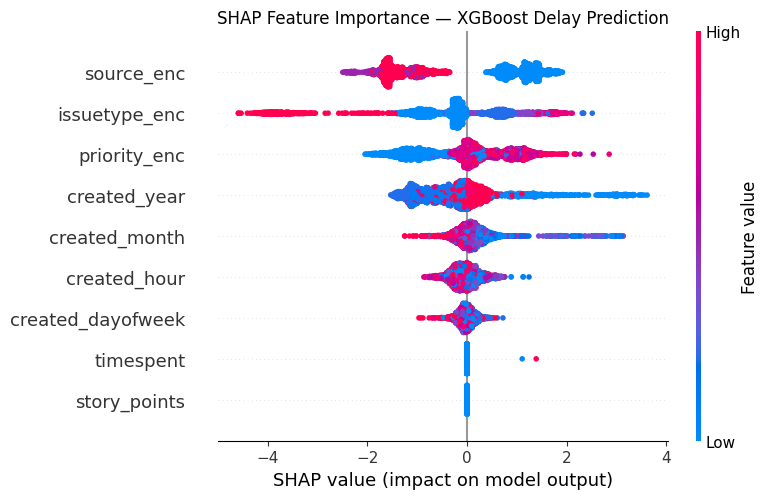

SHAP plot saved to Drive.


In [ ]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

# SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test2)

# Global feature importance plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test2, feature_names=feature_cols_clean, show=False)
plt.title("SHAP Feature Importance — XGBoost Delay Prediction")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ThePublicJiraDataset/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved to Drive.")

In [ ]:
# RQ3: Mitigation mapping based on SHAP findings
mitigation_rules = {
    'source_enc': {
        'finding': 'Repository/team source is top delay predictor',
        'pmbok': 'Resource Management — assess team-level velocity and capacity planning per project source',
        'safe': 'PI Planning — identify team-level systemic delays and address in retrospectives'
    },
    'issuetype_enc': {
        'finding': 'Issue type significantly predicts delay — Bugs delay more than Tasks',
        'pmbok': 'Quality Management — implement defect prevention strategies to reduce bug volume',
        'safe': 'Built-in Quality — enforce Definition of Done to prevent bug accumulation in sprints'
    },
    'priority_enc': {
        'finding': 'Priority level affects resolution time — lower priority issues delayed more',
        'pmbok': 'Scope Management — re-prioritise backlog regularly; deprioritised items accumulate delay',
        'safe': 'Program Backlog — use WSJF scoring to ensure low-value items are explicitly deferred not delayed'
    },
    'created_year': {
        'finding': 'Older issues are more likely to be delayed',
        'pmbok': 'Schedule Management — implement issue age limits; escalate stale issues automatically',
        'safe': 'Iteration Planning — review and close or reassign issues older than 2 sprints'
    },
    'created_month': {
        'finding': 'Seasonal patterns affect delay rates',
        'pmbok': 'Risk Management — flag high-delay months as risk periods in project schedule',
        'safe': 'PI Planning — account for seasonal capacity reduction in PI objectives'
    }
}

print("=== RQ3: SHAP-to-Mitigation Mapping ===\n")
for feature, mapping in mitigation_rules.items():
    print(f"Feature: {feature}")
    print(f"  Finding:  {mapping['finding']}")
    print(f"  PMBOK:    {mapping['pmbok']}")
    print(f"  SAFe:     {mapping['safe']}")
    print()

=== RQ3: SHAP-to-Mitigation Mapping ===

Feature: source_enc
  Finding:  Repository/team source is top delay predictor
  PMBOK:    Resource Management — assess team-level velocity and capacity planning per project source
  SAFe:     PI Planning — identify team-level systemic delays and address in retrospectives

Feature: issuetype_enc
  Finding:  Issue type significantly predicts delay — Bugs delay more than Tasks
  PMBOK:    Quality Management — implement defect prevention strategies to reduce bug volume
  SAFe:     Built-in Quality — enforce Definition of Done to prevent bug accumulation in sprints

Feature: priority_enc
  Finding:  Priority level affects resolution time — lower priority issues delayed more
  PMBOK:    Scope Management — re-prioritise backlog regularly; deprioritised items accumulate delay
  SAFe:     Program Backlog — use WSJF scoring to ensure low-value items are explicitly deferred not delayed

Feature: created_year
  Finding:  Older issues are more likely to be d

In [ ]:
# Save final model results summary
results = {
    'Logistic Regression': {'F1_delayed': 0.62, 'AUC_ROC': 0.7893},
    'Random Forest': {'F1_delayed': 0.73, 'AUC_ROC': 0.8776},
    'XGBoost': {'F1_delayed': 0.73, 'AUC_ROC': 0.8965}
}

import json
with open('/content/drive/MyDrive/ThePublicJiraDataset/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved. All three RQs answered. Ready for write-up.")

Results saved. All three RQs answered. Ready for write-up.


In [ ]:
# Corrected delay label - per source AND issue type
median_days_corrected = df_filtered.groupby(
    ['source', 'issuetype'])['actual_days'].transform('median')

df_filtered['is_delayed_corrected'] = (
    (df_filtered['actual_days'] > median_days_corrected * 1.5) &
    df_filtered['actual_days'].notna()
).astype(int)

print("=== Corrected Delay Label ===")
print(df_filtered['is_delayed_corrected'].value_counts())
print(f"\nOverall class balance: {df_filtered['is_delayed_corrected'].mean():.1%} delayed")

print("\n=== Delay rate by source (should be similar across all three) ===")
print(df_filtered.groupby('source')['is_delayed_corrected'].mean().round(3))

print("\n=== Delay rate by issue type ===")
print(df_filtered.groupby('issuetype')['is_delayed_corrected'].mean().round(3))

=== Corrected Delay Label ===
is_delayed_corrected
0    13808
1     6052
Name: count, dtype: int64

Overall class balance: 30.5% delayed

=== Delay rate by source (should be similar across all three) ===
source
Apache     0.246
Jira       0.424
MongoDB    0.349
Name: is_delayed_corrected, dtype: float64

=== Delay rate by issue type ===
issuetype
Bug            0.334
Improvement    0.300
New Feature    0.405
Sub-task       0.231
Suggestion     0.416
Task           0.020
Name: is_delayed_corrected, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json

# Reload raw issues
with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/Apache_issues.json') as f:
    apache = json.load(f)
with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/Jira_issues.json') as f:
    jira = json.load(f)
with open('/content/drive/MyDrive/ThePublicJiraDataset/3. DataDump/MongoDB_issues.json') as f:
    mongodb = json.load(f)

# Flatten
def flatten_issue(issue, source):
    fields = issue.get('fields', {})
    return {
        'id': issue.get('id'),
        'key': issue.get('key'),
        'source': source,
        'created': fields.get('created'),
        'resolutiondate': fields.get('resolutiondate'),
        'status': fields.get('status', {}).get('name') if fields.get('status') else None,
        'priority': fields.get('priority', {}).get('name') if fields.get('priority') else None,
        'issuetype': fields.get('issuetype', {}).get('name') if fields.get('issuetype') else None,
        'assignee': fields.get('assignee', {}).get('displayName') if fields.get('assignee') else None,
        'story_points': fields.get('story_points') or fields.get('customfield_12310293') or fields.get('customfield_10555'),
        'timespent': fields.get('timespent'),
        'timeoriginalestimate': fields.get('timeoriginalestimate'),
        'summary': fields.get('summary'),
    }

rows = []
for issue in apache: rows.append(flatten_issue(issue, 'Apache'))
for issue in jira: rows.append(flatten_issue(issue, 'Jira'))
for issue in mongodb: rows.append(flatten_issue(issue, 'MongoDB'))

df = pd.DataFrame(rows)

# Filter issue types
keep_types = ['Bug', 'Improvement', 'Task', 'New Feature', 'Suggestion', 'Sub-task']
df_filtered = df[df['issuetype'].isin(keep_types)].copy()

# Convert dates
df_filtered['created'] = pd.to_datetime(df_filtered['created'], utc=True, errors='coerce')
df_filtered['resolutiondate'] = pd.to_datetime(df_filtered['resolutiondate'], utc=True, errors='coerce')
df_filtered['actual_days'] = (df_filtered['resolutiondate'] - df_filtered['created']).dt.total_seconds() / 86400

print(f"Rebuilt: {df_filtered.shape}")

Mounted at /content/drive
Rebuilt: (19860, 14)


/tmp/ipykernel_3303/1118105118.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['created'] = pd.to_datetime(df_filtered['created'], utc=True, errors='coerce')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Feature engineering with corrected label
df_features = df_filtered.copy()
df_features['created'] = pd.to_datetime(df_features['created'], utc=True, errors='coerce')
df_features['created_hour'] = df_features['created'].dt.hour
df_features['created_dayofweek'] = df_features['created'].dt.dayofweek
df_features['created_month'] = df_features['created'].dt.month
df_features['created_year'] = df_features['created'].dt.year
df_features['priority_enc'] = df_features['priority'].astype('category').cat.codes
df_features['issuetype_enc'] = df_features['issuetype'].astype('category').cat.codes
df_features['source_enc'] = df_features['source'].astype('category').cat.codes
df_features['story_points'] = df_features['story_points'].fillna(0)
df_features['timespent'] = df_features['timespent'].fillna(0)

feature_cols = [
    'created_hour', 'created_dayofweek', 'created_month', 'created_year',
    'priority_enc', 'issuetype_enc', 'source_enc',
    'story_points', 'timespent'
]

X = df_features[feature_cols].dropna()
y = df_features.loc[X.index, 'is_delayed_corrected']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(scaler.fit_transform(X_train), y_train)
y_pred_lr = lr.predict(scaler.transform(X_test))
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(scaler.transform(X_test))[:,1]):.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.70      0.93      0.80      2704
           1       0.45      0.13      0.20      1211

    accuracy                           0.68      3915
   macro avg       0.58      0.53      0.50      3915
weighted avg       0.62      0.68      0.62      3915

AUC-ROC: 0.6840

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2704
           1       0.54      0.47      0.50      1211

    accuracy                           0.71      3915
   macro avg       0.66      0.65      0.65      3915
weighted avg       0.70      0.71      0.71      3915

AUC-ROC: 0.7646

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      2704
           1       0.59      0.41      0.48      1211

    accuracy                           0.73      3915
   macro avg       0.68     

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("SHAP Feature Importance — XGBoost (Corrected Label)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ThePublicJiraDataset/shap_summary_corrected.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

NameError: name 'xgb' is not defined